# Blood Cancer Model — Training

Data preparation (class balancing, train/val/test split) and ResNet50 transfer-learning training. Saves the best checkpoint as `best_model.pth`.

Run this notebook first. Once training finishes and `best_model.pth` is saved, use the separate **Evaluation** notebook to test it — no need to re-run training.

In [1]:
# Connect with google drive
import os
from google.colab import drive
# Use force_remount=True to bypass the 'Mountpoint must not already contain files' error
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# List contents of your Google Drive
data = os.listdir('/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/AML-Cytomorphology-JPG')
print(data)



['PMB', 'PMO', 'MYO', 'NGS', 'MOB', 'NGB', 'MYB', 'MON', 'MMZ', 'LYT', 'KSC', 'EOS', 'LYA', 'EBO', 'BAS']


In [12]:
import pandas as pd
import os

def get_counts(path, classes):
    return {cls: len(os.listdir(os.path.join(path, cls))) for cls in classes}

# Correcting the path (removing the trailing single quote from previous state)
data_path = "/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/AML-Cytomorphology-JPG"

# 'data' variable contains the class names from the os.listdir output in the previous cell
classes = sorted(data)
counts = get_counts(data_path, classes)

# Create summary dataframe
balance_df = pd.DataFrame({
    'Class': counts.keys(),
    'Count': counts.values()
})

display(balance_df)
print(f"\nTotal Images in Dataset: {sum(counts.values())}")

,Class,Count
0,BAS,79
1,EBO,78
2,EOS,424
3,KSC,15
4,LYA,11
5,LYT,3937
6,MMZ,15
7,MOB,26
8,MON,1789
9,MYB,42



Total Images in Dataset: 18365


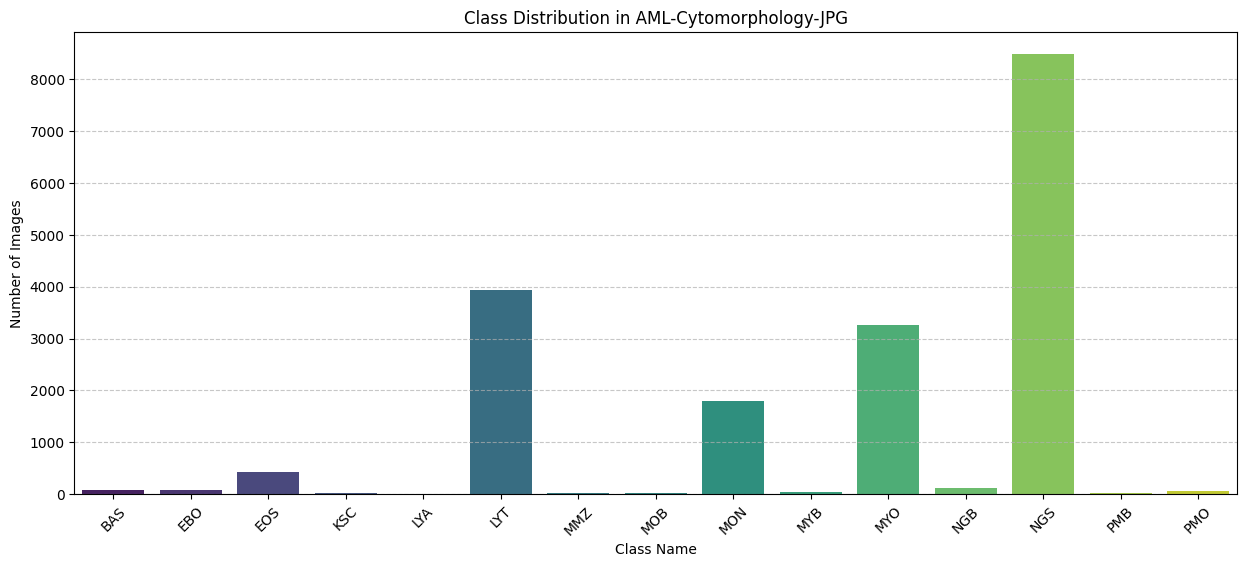

In [14]:
# plot the graph for the single directory distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
# Fixed the warning by adding hue='Class' and legend=False
sns.barplot(data=balance_df, x='Class', y='Count', hue='Class', palette='viridis', legend=False)
plt.title('Class Distribution in AML-Cytomorphology-JPG')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
import shutil
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import os

In [ ]:
# Create New Dataset Structure
new_dataset_path = '/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/new_dataset'
os.makedirs(new_dataset_path, exist_ok=True)

In [13]:
# Process Dataset
rare_classes = ['KSC', 'LYA', 'MMZ', 'PMB', 'MOB']

# Fix: Iterate directly over 'data' (which is a list) instead of calling os.listdir(data)
for class_name in data:

    class_path = os.path.join(data_path, class_name)

    if not os.path.isdir(class_path):
        continue

    # Rename rare classes to OTHER
    if class_name in rare_classes:
        target_class = "OTHER"
    else:
        target_class = class_name

    target_path = os.path.join(new_dataset_path, target_class)

    os.makedirs(target_path, exist_ok=True)

    for image_name in os.listdir(class_path):

        source = os.path.join(class_path, image_name)
        destination = os.path.join(target_path, image_name)

        shutil.copy(source, destination)

NameError: name 'new_dataset_path' is not defined

In [ ]:
# Verify the new dataset balance
new_classes = os.listdir(new_dataset_path)
new_counts = {cls: len(os.listdir(os.path.join(new_dataset_path, cls))) for cls in new_classes}

new_balance_df = pd.DataFrame({
    'Class': new_counts.keys(),
    'Count': new_counts.values()
}).sort_values('Count', ascending=False)

display(new_balance_df)

plt.figure(figsize=(15, 6))
sns.barplot(data=new_balance_df, x='Class', y='Count', hue='Class', palette='magma', legend=False)
plt.title('Class Distribution in New Dataset (with OTHER category)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# check Final Classes
for class_name in os.listdir(new_dataset_path):
    class_path = os.path.join(new_dataset_path, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name}: {count} images")

In [ ]:
# Calculate the imbalance ratio
majority_class = new_balance_df.iloc[0]
minority_class = new_balance_df.iloc[-1]

ratio = minority_class['Count'] / majority_class['Count']

print(f"Majority Class: {majority_class['Class']} ({majority_class['Count']} images)")
print(f"Minority Class: {minority_class['Class']} ({minority_class['Count']} images)")
print(f"Ratio (Minority/Majority): {ratio:.4f}")
print(f"The majority class is approximately {1/ratio:.1f}x larger than the minority class.")

In [16]:
# Create  Train/Validation/Test Split
split_dataset_path = "/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/final_dataset"

splits = ['train', 'val', 'test']

for split in splits:
    os.makedirs(os.path.join(split_dataset_path, split), exist_ok=True)

In [17]:
# Split Dataset
# List of folders to ignore if they exist in the source directory
ignore_folders = ['train', 'val', 'test']

for class_name in os.listdir(new_dataset_path):
    # Skip the destination split folders if they are in the same parent directory
    if class_name in ignore_folders:
        continue

    class_path = os.path.join(new_dataset_path, class_name)

    # Ensure we are only looking at directories
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    # Skip if folder is empty to avoid ValueError
    if len(images) == 0:
        print(f"Skipping empty folder: {class_name}")
        continue

    # Train split (70%)
    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    # Validation + Test split (15% each)
    val_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=42
    )

    split_data = {
        'train': train_images,
        'val': val_images,
        'test': test_images
    }

    for split_name, split_images in split_data.items():
        split_class_path = os.path.join(
            split_dataset_path,
            split_name,
            class_name
        )

        os.makedirs(split_class_path, exist_ok=True)

        for image_name in split_images:
            source = os.path.join(class_path, image_name)
            destination = os.path.join(split_class_path, image_name)
            shutil.copy(source, destination)

print("Dataset splitting completed successfully.")

NameError: name 'new_dataset_path' is not defined

In [ ]:
# Verify final split distribution
for split in ['train', 'val', 'test']:
    total = 0
    split_path = os.path.join(split_dataset_path, split)
    print(f"--- {split.upper()} SPLIT ---")
    for class_name in sorted(os.listdir(split_path)):
        count = len(os.listdir(os.path.join(split_path, class_name)))
        total += count
        print(f"{class_name}: {count}")
    print(f"Total {split}: {total}\n")

In [18]:
# import Libraries
# Import basic libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import image library
from PIL import Image

# Import PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Import torchvision libraries
from torchvision import datasets, transforms, models

# Import DataLoader
from torch.utils.data import DataLoader

# Import evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Import class weight function
from sklearn.utils.class_weight import compute_class_weight

# Import seaborn
import seaborn as sns

In [19]:
# Check GPU availability
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [20]:
# Define dataset path
dataset_path = "/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/final_dataset"

# Define train path
train_dir = dataset_path + "/train"

# Define validation path
val_dir = dataset_path + "/val"

# Define test path
test_dir = dataset_path + "/test"

In [21]:
# Training transformations
train_transforms = transforms.Compose([

    # Resize images
    transforms.Resize((224, 224)),

    # Apply horizontal flip
    transforms.RandomHorizontalFlip(),

    # Apply small rotation
    transforms.RandomRotation(10),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize images
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Validation and test transformations
val_test_transforms = transforms.Compose([

    # Resize images
    transforms.Resize((224, 224)),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize images
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:
# Load training dataset
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

# Load validation dataset
val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transforms
)

# Load test dataset
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transforms
)

In [23]:
# Create training dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

# Create validation dataloader
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

# Create test dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [26]:
# Get class names
class_names = train_dataset.classes

# Print class names
print(class_names)

['BAS', 'EBO', 'EOS', 'LYT', 'MON', 'MYB', 'MYO', 'NGB', 'NGS', 'OTHER', 'PMO']


In [25]:
# Get target labels
targets = train_dataset.targets

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(targets),
    y=targets
)

# Convert to tensor
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print(class_weights)

tensor([21.2397, 21.6330,  3.9466,  0.4240,  0.9331, 40.2821,  0.5108, 15.3708,
         0.1967, 19.7997, 23.8404], device='cuda:0')


In [27]:
# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

In [ ]:
# Get number of input features
num_features = model.fc.in_features

# Modify final classification layer
model.fc = nn.Sequential(

    # Dropout layer
    nn.Dropout(0.5),

    # First dense layer
    nn.Linear(num_features, 256),

    # Activation function
    nn.ReLU(),

    # Dropout layer
    nn.Dropout(0.3),

    # Output layer
    nn.Linear(256, len(class_names))
)

In [ ]:
# Move model to GPU
model = model.to(device)

In [ ]:
# Define loss function
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [ ]:
# Define optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# Define scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=2
)

In [2]:
# Create checkpoint folder
checkpoint_path = "/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/final_dataset/checkpoints"

os.makedirs(checkpoint_path, exist_ok=True)

# Number of epochs
num_epochs = 10

# Best validation accuracy
best_val_accuracy = 0.0

# Lists for storing losses and accuracies
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [ ]:
import torch
from tqdm import tqdm

In [ ]:
# Start training loop
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # Training mode
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for training
    train_bar = tqdm(
        train_loader,
        desc="Training",
        leave=True
    )

    # Training loop
    for images, labels in train_bar:

        # Move images to GPU
        images = images.to(device)

        # Move labels to GPU
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Add loss
        running_loss += loss.item()

        # Get predictions
        _, predicted = torch.max(outputs, 1)

        # Count total labels
        total += labels.size(0)

        # Count correct predictions
        correct += (predicted == labels).sum().item()

        # Calculate current accuracy
        accuracy = correct / total

        # Update progress bar
        train_bar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Accuracy": f"{accuracy:.4f}"
        })

    # Average training loss
    train_loss = running_loss / len(train_loader)

    # Training accuracy
    train_accuracy = correct / total

    # Store training values
    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    # Validation mode
    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    # Validation progress bar
    val_bar = tqdm(
        val_loader,
        desc="Validation",
        leave=True
    )

    # Disable gradients
    with torch.no_grad():

        # Validation loop
        for images, labels in val_bar:

            # Move data to GPU
            images = images.to(device)

            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Add validation loss
            val_loss += loss.item()

            # Get predictions
            _, predicted = torch.max(outputs, 1)

            # Count labels
            total += labels.size(0)

            # Count correct predictions
            correct += (predicted == labels).sum().item()

            # Calculate validation accuracy
            accuracy = correct / total

            # Update validation progress bar
            val_bar.set_postfix({
                "Val Loss": f"{loss.item():.4f}",
                "Val Accuracy": f"{accuracy:.4f}"
            })

    # Average validation loss
    val_loss = val_loss / len(val_loader)

    # Validation accuracy
    val_accuracy = correct / total

    # Store validation results
    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    # Update scheduler
    scheduler.step(val_loss)

    # Print epoch results
    print(f"\nTrain Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_accuracy:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Validation Accuracy: {val_accuracy:.4f}")

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            checkpoint_path + "/best_model.pth"
        )

        print("Best model saved!")


Epoch 1/10


Validation: 100%|██████████| 173/173 [15:40<00:00,  5.43s/it, Val Loss=2.4803, Val Accuracy=0.7053]



Train Loss: 2.0746
Train Accuracy: 0.4847
Validation Loss: 1.3589
Validation Accuracy: 0.7053
Best model saved!

Epoch 2/10


Validation: 100%|██████████| 173/173 [00:26<00:00,  6.45it/s, Val Loss=2.4755, Val Accuracy=0.7753]



Train Loss: 1.7705
Train Accuracy: 0.6440
Validation Loss: 1.0568
Validation Accuracy: 0.7753
Best model saved!

Epoch 3/10


...


Train Loss: 1.3347
Train Accuracy: 0.6976
Validation Loss: 0.9449
Validation Accuracy: 0.7593

Epoch 9/10


Validation: 100%|██████████| 173/173 [00:27<00:00,  6.38it/s, Val Loss=1.0533, Val Accuracy=0.8083]



Train Loss: 1.3105
Train Accuracy: 0.7033
Validation Loss: 0.7771
Validation Accuracy: 0.8083

Epoch 10/10


Validation: 100%|██████████| 173/173 [00:26<00:00,  6.53it/s, Val Loss=1.2163, Val Accuracy=0.7336]


Train Loss: 1.3199
Train Accuracy: 0.6885
Validation Loss: 0.9100
Validation Accuracy: 0.7336
